# Computer Vision Mini project Teacher Assessment-2
## Name - Kunal Kothe
## Roll - A4-71

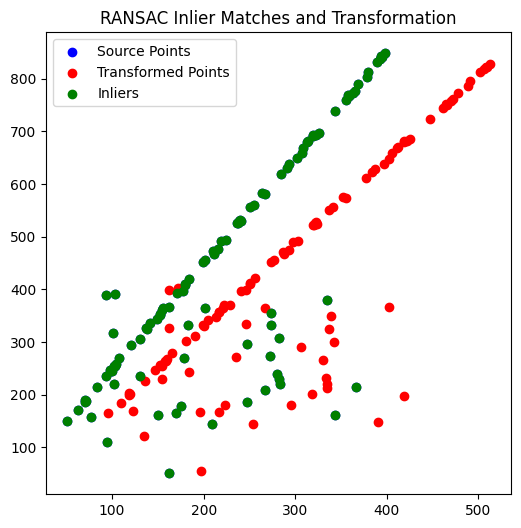

Estimated Transformation Matrix:
[[ 1.          0.1        30.00000134]
 [-0.09999999  1.         20.00000057]]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load the source and destination points
src_pts = np.load("ransac_src_pts.npy")
dst_pts = np.load("ransac_dst_pts.npy")

# Estimate the transformation using RANSAC
transformation_matrix, inliers = cv2.estimateAffine2D(src_pts, dst_pts, method=cv2.RANSAC, ransacReprojThreshold=5.0)

# Get inlier points
inlier_src_pts = src_pts[inliers.ravel() == 1]
inlier_dst_pts = dst_pts[inliers.ravel() == 1]

# Apply the transformation to the source points
transformed_src_pts = cv2.transform(np.array([src_pts]), transformation_matrix)[0]

# Plot the results
plt.figure(figsize=(6, 6))
plt.scatter(src_pts[:, 0], src_pts[:, 1], color='blue', label='Source Points')
plt.scatter(dst_pts[:, 0], dst_pts[:, 1], color='red', label='Transformed Points')
plt.scatter(inlier_src_pts[:, 0], inlier_src_pts[:, 1], color='green', label='Inliers')
plt.legend()
plt.title("RANSAC Inlier Matches and Transformation")
plt.show()

# Print transformation matrix
print("Estimated Transformation Matrix:")
print(transformation_matrix)
